# NYC Housing Violations - Exploratory Data Analysis

**Goal:** Uncover patterns of housing code violations across NYC to identify:
- Geographic clusters of violations
- Most common violation types
- Differences across boroughs and neighborhoods
- Enforcement patterns and gaps

This analysis exposes landlord neglect and enforcement failures to support tenant advocacy.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from datetime import datetime

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Data

In [2]:
# Load violations data (cleaned version)
df = pd.read_csv('../data/processed/violations_cleaned.csv')

# Parse dates (they're saved as strings in CSV)
date_cols = ['inspectiondate', 'approveddate', 'currentstatusdate']
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

print(f"Loaded {len(df):,} violation records")
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.shape[1]}")
print(f"Rows: {df.shape[0]}")

Loaded 10,000 violation records

Dataset shape: (10000, 45)
Columns: 45
Rows: 10000


## 2. Initial Data Inspection

In [3]:
# Display first few rows
df.head(10)

,violationid,buildingid,registrationid,boroid,boro,housenumber,lowhousenumber,highhousenumber,streetname,streetcode,zip,apartment,story,block,lot,class,inspectiondate,approveddate,ordernumber,novdescription,currentstatusid,currentstatus,currentstatusdate,violationstatus,rentimpairing,latitude,longitude,communityboard,councildistrict,censustract,bin,bbl,nta,class_description,full_address,inspection_year,inspection_month,inspection_month_name,inspection_day_of_week,inspection_quarter,days_to_status_change,is_open,is_severe,is_rent_impairing,severity_score
0,18395142,8229,119130,1,MANHATTAN,4220,4220,4228,Broadway,13610,10033,2D,2.0,2163,25,A,2025-11-17,2025-11-17,556,§ 27-2013 ADM CODE PAINT WITH LIGHT COLORED PA...,1,VIOLATION OPEN,2025-11-17,Open,N,40.849024,-73.936963,12.0,10.0,263.0,1063916.0,1.021630e+09,Washington Heights (South),Non-hazardous,"4220 Broadway, MANHATTAN, NY 10033",2025,11,November,Monday,4,0,True,False,False,1
1,18395102,422684,0,4,QUEENS,22-54,22-54,22-54,35 Street,8640,11105,1FL,1.0,832,77,A,2025-11-17,2025-11-17,856,§ 27-2013 ADMIN. CODE: PAINT WITH LIGHT COLORE...,1,VIOLATION OPEN,2025-11-17,Open,N,40.773933,-73.910060,1.0,22.0,117.0,4017031.0,4.008320e+09,Astoria (North)-Ditmars-Steinway,Non-hazardous,"22-54 35 Street, QUEENS, NY 11105",2025,11,November,Monday,4,0,True,False,False,1
2,18395101,484610,406280,4,QUEENS,34-49,34-49,34-49,81 Street,16740,11372,5Y,5.0,1268,33,A,2025-11-17,2025-11-17,556,§ 27-2013 ADM CODE PAINT WITH LIGHT COLORED PA...,1,VIOLATION OPEN,2025-11-17,Open,N,40.752653,-73.885776,3.0,25.0,283.0,4029199.0,4.012680e+09,Jackson Heights,Non-hazardous,"34-49 81 Street, QUEENS, NY 11372",2025,11,November,Monday,4,0,True,False,False,1
3,18395100,192713,0,3,BROOKLYN,9816,9816,9816,Avenue N,14280,11236,1STFLO,1.0,8301,44,A,2025-11-17,2025-11-17,856,§ 27-2013 ADMIN. CODE: PAINT WITH LIGHT COLORE...,1,VIOLATION OPEN,2025-11-17,Open,N,40.636167,-73.890476,18.0,46.0,1022.0,3234580.0,3.083010e+09,Canarsie,Non-hazardous,"9816 Avenue N, BROOKLYN, NY 11236",2025,11,November,Monday,4,0,True,False,False,1
4,18395099,808943,374358,3,BROOKLYN,37,27,39,New Lots Avenue,64530,11212,5I,5.0,3628,1,A,2025-11-17,2025-11-17,556,§ 27-2013 ADM CODE PAINT WITH LIGHT COLORED PA...,1,VIOLATION OPEN,2025-11-17,Open,N,40.657061,-73.903817,16.0,42.0,920.0,3326601.0,3.036280e+09,Brownsville,Non-hazardous,"37 New Lots Avenue, BROOKLYN, NY 11212",2025,11,November,Monday,4,0,True,False,False,1
5,18395096,373362,365427,3,BROOKLYN,110,110,110,St James Place,80230,11238,8,3.0,1963,45,C,2025-11-17,2025-11-17,617,§ 27-2056.6 ADM CODE - CORRECT THE LEAD-BASED ...,1,VIOLATION OPEN,2025-11-17,Open,N,40.686424,-73.964394,2.0,35.0,201.0,3056066.0,3.019630e+09,Clinton Hill,Immediately hazardous,"110 St James Place, BROOKLYN, NY 11238",2025,11,November,Monday,4,0,True,True,False,3
6,18395095,373362,365427,3,BROOKLYN,110,110,110,St James Place,80230,11238,8,3.0,1963,45,C,2025-11-17,2025-11-17,617,§ 27-2056.6 ADM CODE - CORRECT THE LEAD-BASED ...,1,VIOLATION OPEN,2025-11-17,Open,N,40.686424,-73.964394,2.0,35.0,201.0,3056066.0,3.019630e+09,Clinton Hill,Immediately hazardous,"110 St James Place, BROOKLYN, NY 11238",2025,11,November,Monday,4,0,True,True,False,3
7,18395094,373362,365427,3,BROOKLYN,110,110,110,St James Place,80230,11238,8,3.0,1963,45,C,2025-11-17,2025-11-17,617,§ 27-2056.6 ADM CODE - CORRECT THE LEAD-BASED ...,1,VIOLATION OPEN,2025-11-17,Open,N,40.686424,-73.964394,2.0,35.0,201.0,3056066.0,3.019630e+09,Clinton Hill,Immediately hazardous,"110 St James Place, BROOKLYN, NY 11238",2025,11,November,Monday,4,0,True,True,False,3
8,18395092,3644,109256,1,MANHATTAN,2566,2566,2566,Adam C Powell Boulevard,10610,10039,5B,5.0,2034,32,C,2025-11-17,2025-11-17,616,§ 27-2056.6 ADM CODE - CORRECT THE LEAD-BASED ...,1,VIOLATION OPEN,2025-11-16,Open,N,40.823809,-73.937510,10.0,9.0,234.0,1060564.0,1.020340e+09,Harlem (North),Immediately hazardous,"2566 Adam C Powell Boulevard, MANHATTAN, NY 10039",2025,11,November,Monday,4,-1,True,True,False,3

In [4]:
# Column information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   violationid             10000 non-null  int64         
 1   buildingid              10000 non-null  int64         
 2   registrationid          10000 non-null  int64         
 3   boroid                  10000 non-null  int64         
 4   boro                    10000 non-null  object        
 5   housenumber             10000 non-null  object        
 6   lowhousenumber          9998 non-null   object        
 7   highhousenumber         10000 non-null  object        
 8   streetname              10000 non-null  object        
 9   streetcode              10000 non-null  int64         
 10  zip                     10000 non-null  int64         
 11  apartment               783 non-null    object        
 12  story                   987 non-null    float64

In [5]:
# Basic statistics
df.describe()

,violationid,buildingid,registrationid,boroid,streetcode,zip,story,block,lot,inspectiondate,approveddate,ordernumber,currentstatusid,currentstatusdate,latitude,longitude,communityboard,councildistrict,censustract,bin,bbl,inspection_year,inspection_month,inspection_quarter,days_to_status_change,severity_score
count,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,987.000000,10000.000000,10000.000000,10000,10000,10000.000000,10000.000000,10000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9.992000e+03,9.992000e+03,10000.0,10000.0,10000.0,10000.000000,10000.000000
mean,1.838433e+07,1.958140e+05,170589.421800,1.495000,31933.628900,10248.761200,4.333333,2174.547200,517.405100,2025-11-17 00:00:00,2025-11-17 00:00:00,765.095400,24.397400,2025-11-16 23:57:41.760000,40.794667,-73.935205,6.530753,10.461746,3986.538354,1.545383e+06,1.516946e+09,2025.0,11.0,4.0,-0.001600,0.226100
min,1.837648e+07,4.000000e+00,0.000000,1.000000,0.000000,10001.000000,0.000000,16.000000,1.000000,2025-11-17 00:00:00,2025-11-17 00:00:00,484.000000,1.000000,2025-11-12 00:00:00,40.562585,-74.118165,1.000000,1.000000,2.000000,1.000000e+06,1.000160e+09,2025.0,11.0,4.0,-5.000000,0.000000
25%,1.838204e+07,2.417325e+04,120557.500000,1.000000,18530.000000,10024.000000,1.000000,1206.000000,19.000000,2025-11-17 00:00:00,2025-11-17 00:00:00,780.000000,27.000000,2025-11-17 00:00:00,40.758874,-73.975580,3.000000,5.000000,122.000000,1.043752e+06,1.012170e+09,2025.0,11.0,4.0,0.000000,0.000000
50%,1.838454e+07,4.290150e+04,140121.500000,1.000000,31120.000000,10035.000000,2.000000,1947.000000,39.000000,2025-11-17 00:00:00,2025-11-17 00:00:00,780.000000,27.000000,2025-11-17 00:00:00,40.807584,-73.943073,7.000000,9.000000,208.000000,1.075554e+06,1.020230e+09,2025.0,11.0,4.0,0.000000,0.000000
75%,1.838704e+07,1.107098e+05,216132.750000,2.000000,36690.000000,10457.250000,4.000000,2872.000000,67.250000,2025-11-17 00:00:00,2025-11-17 00:00:00,780.000000,27.000000,2025-11-17 00:00:00,40.833989,-73.901619,10.000000,15.000000,387.000000,2.017173e+06,2.029330e+09,2025.0,11.0,4.0,0.000000,0.000000
max,1.839514e+07,1.017046e+06,928722.000000,5.000000,95200.000000,11694.000000,691.000000,16155.000000,7511.000000,2025-11-17 00:00:00,2025-11-17 00:00:00,1506.000000,27.000000,2025-11-17 00:00:00,40.905645,-73.751275,18.000000,50.000000,116302.000000,5.106233e+06,5.039830e+09,2025.0,11.0,4.0,0.000000,3.000000
std,3.404950e+03,3.143069e+05,78206.869161,0.677511,17190.431131,316.887754,31.069564,1493.576454,1804.875012,NaN,NaN,78.628133,7.803856,NaN,0.050689,0.047966,3.443951,7.840051,9684.437187,6.959045e+05,6.886113e+08,0.0,0.0,0.0,0.087168,0.720021


In [6]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_pct
}).sort_values('Missing Values', ascending=False)

print("Missing Values by Column:")
missing_df[missing_df['Missing Values'] > 0]

Missing Values by Column:


,Missing Values,Percentage
apartment,9217,92.17
story,9013,90.13
bin,8,0.08
bbl,8,0.08
lowhousenumber,2,0.02
longitude,1,0.01
communityboard,1,0.01
councildistrict,1,0.01
censustract,1,0.01
nta,1,0.01


## 3. Violation Class Analysis

NYC violations are classified as:
- **Class A**: Non-hazardous (e.g., peeling paint, missing smoke detector)
- **Class B**: Hazardous (e.g., broken heat, water leaks)
- **Class C**: Immediately hazardous (e.g., no heat in winter, structural issues)

In [7]:
# Violation class distribution
class_counts = df['class'].value_counts().sort_index()
print("Violation Class Distribution:")
print(class_counts)
print(f"\nPercentage:")
print((class_counts / len(df) * 100).round(2))

Violation Class Distribution:
class
A     156
B     388
C     443
I    9013
Name: count, dtype: int64

Percentage:
class
A     1.56
B     3.88
C     4.43
I    90.13
Name: count, dtype: float64


ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (3).

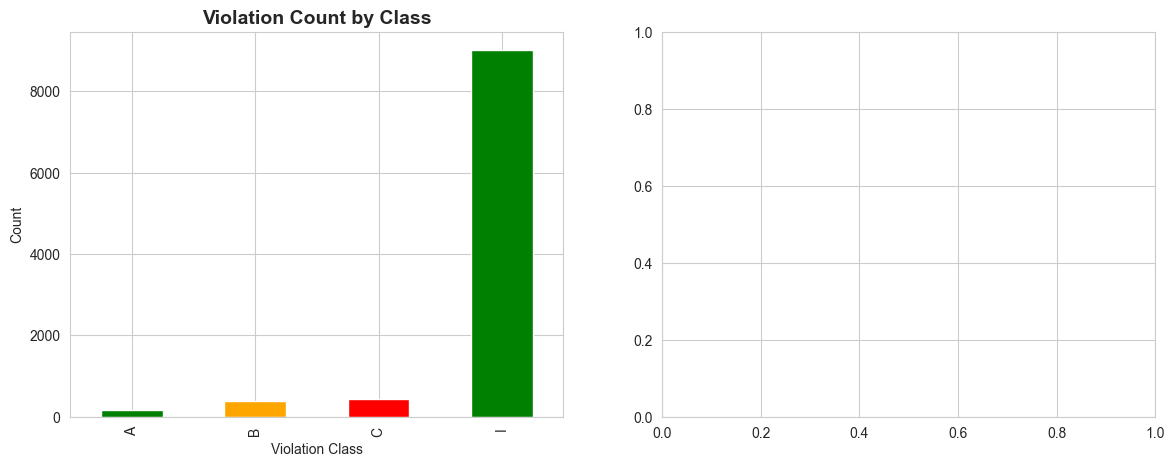

In [8]:
# Visualize violation classes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
class_counts.plot(kind='bar', ax=ax1, color=['green', 'orange', 'red'])
ax1.set_title('Violation Count by Class', fontsize=14, fontweight='bold')
ax1.set_xlabel('Violation Class')
ax1.set_ylabel('Count')
ax1.set_xticklabels(['A (Non-hazardous)', 'B (Hazardous)', 'C (Immediately hazardous)'], rotation=45)

# Pie chart
class_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=['green', 'orange', 'red'])
ax2.set_title('Violation Distribution by Severity', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

## 4. Geographic Analysis - Borough Comparison

In [ ]:
# Violations by borough
boro_counts = df['boro'].value_counts()
print("Violations by Borough:")
print(boro_counts)
print(f"\nPercentage:")
print((boro_counts / len(df) * 100).round(2))

In [ ]:
# Borough visualization
plt.figure(figsize=(12, 6))
boro_counts.plot(kind='barh', color='steelblue')
plt.title('Housing Violations by NYC Borough', fontsize=16, fontweight='bold')
plt.xlabel('Number of Violations')
plt.ylabel('Borough')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Violation severity by borough
boro_class = pd.crosstab(df['boro'], df['class'], normalize='index') * 100
boro_class = boro_class.round(2)

print("Violation Class Distribution by Borough (percentage):")
print(boro_class)

In [ ]:
# Stacked bar chart
boro_class_counts = pd.crosstab(df['boro'], df['class'])

boro_class_counts.plot(kind='bar', stacked=True, figsize=(12, 6), 
                       color=['green', 'orange', 'red'])
plt.title('Violation Severity by Borough', fontsize=16, fontweight='bold')
plt.xlabel('Borough')
plt.ylabel('Number of Violations')
plt.legend(title='Class', labels=['A (Non-hazardous)', 'B (Hazardous)', 'C (Immediately hazardous)'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Top Violation Types

In [ ]:
# Most common violation descriptions
top_violations = df['novdescription'].value_counts().head(15)

print("Top 15 Most Common Violations:")
for i, (violation, count) in enumerate(top_violations.items(), 1):
    print(f"{i}. {violation}: {count:,} ({count/len(df)*100:.1f}%)")

In [ ]:
# Visualize top violations
plt.figure(figsize=(12, 8))
top_violations.plot(kind='barh', color='coral')
plt.title('Top 15 Most Common Housing Violations', fontsize=16, fontweight='bold')
plt.xlabel('Number of Violations')
plt.ylabel('Violation Description')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Violation Status Analysis

In [ ]:
# Current status distribution
status_counts = df['currentstatus'].value_counts()
print("Violation Status Distribution:")
print(status_counts)
print(f"\nPercentage:")
print((status_counts / len(df) * 100).round(2))

In [ ]:
# Visualize status
plt.figure(figsize=(10, 6))
status_counts.plot(kind='bar', color='skyblue')
plt.title('Violation Status Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Neighborhood Analysis (Top 20 Neighborhoods)

In [ ]:
# Top neighborhoods with violations
top_neighborhoods = df['nta'].value_counts().head(20)

print("Top 20 Neighborhoods with Most Violations:")
for i, (neighborhood, count) in enumerate(top_neighborhoods.items(), 1):
    print(f"{i}. {neighborhood}: {count:,}")

In [ ]:
# Visualize top neighborhoods
plt.figure(figsize=(12, 8))
top_neighborhoods.plot(kind='barh', color='teal')
plt.title('Top 20 Neighborhoods by Violation Count', fontsize=16, fontweight='bold')
plt.xlabel('Number of Violations')
plt.ylabel('Neighborhood')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Key Findings Summary

Based on our initial exploration, we can identify:
1. **Violation severity patterns** across the city
2. **Geographic concentration** of violations
3. **Most common types** of housing code violations
4. **Enforcement gaps** (open vs. closed violations)

### Next Steps:
- Temporal analysis (violation trends over time)
- Geospatial clustering (identify hotspots)
- Building-level analysis (repeat offenders)
- Enforcement equity analysis (response times by neighborhood)